In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

In [ ]:
# URL of the dataset
dataset_url = "http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data_10_percent.gz" # 10% of the dataset
# dataset_url  = "http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data.gz" # Full dataset

In [ ]:
# URL of the dataset
url = "http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data_10_percent.gz"
# url = "http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data.gz"

# 41 Features + 1 attack type
feature_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
    "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login",
    "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "attack_type"
]

In [ ]:
# Load the dataset
data = pd.read_csv(url, names=feature_names, header=None)

# Drop categorical features
categorical_features = ["protocol_type", "service", "flag"]
data = data.drop(columns=categorical_features)

# Mark 'attack_type' as binary: 0 for "normal.", 1 for any attack
data["attack_type"] = data["attack_type"].apply(lambda x: 0 if x == "normal." else 1)

# Display the first few rows of the processed dataset
data

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type
0,0,181,5450,0,0,0,0,0,1,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,0
1,0,239,486,0,0,0,0,0,1,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,0
2,0,235,1337,0,0,0,0,0,1,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,0
3,0,219,1337,0,0,0,0,0,1,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,0
4,0,217,2032,0,0,0,0,0,1,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
# Display basic info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 39 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494021 non-null  int64  
 1   src_bytes                    494021 non-null  int64  
 2   dst_bytes                    494021 non-null  int64  
 3   land                         494021 non-null  int64  
 4   wrong_fragment               494021 non-null  int64  
 5   urgent                       494021 non-null  int64  
 6   hot                          494021 non-null  int64  
 7   num_failed_logins            494021 non-null  int64  
 8   logged_in                    494021 non-null  int64  
 9   num_compromised              494021 non-null  int64  
 10  root_shell                   494021 non-null  int64  
 11  su_attempted                 494021 non-null  int64  
 12  num_root                     494021 non-null  int64  
 13 

In [ ]:
# Display summary statistics
data.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type
count,494021.000000,4.940210e+05,4.940210e+05,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,...,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000
mean,47.979302,3.025610e+03,8.685324e+02,0.000045,0.006433,0.000014,0.034519,0.000152,0.148247,0.010212,...,188.665670,0.753780,0.030906,0.601935,0.006684,0.176754,0.176443,0.058118,0.057412,0.803089
std,707.746472,9.882181e+05,3.304000e+04,0.006673,0.134805,0.005510,0.782103,0.015520,0.355345,1.798326,...,106.040437,0.410781,0.109259,0.481309,0.042133,0.380593,0.380919,0.230590,0.230140,0.397665
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4.500000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,46.000000,0.410000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,5.200000e+02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,1.032000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,1.000000,0.040000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,58329.000000,6.933756e+08,5.155468e+06,1.000000,3.000000,3.000000,30.000000,5.000000,1.000000,884.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Check for missing values
data.isnull().sum()

,0
duration,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0
num_failed_logins,0
logged_in,0
num_compromised,0


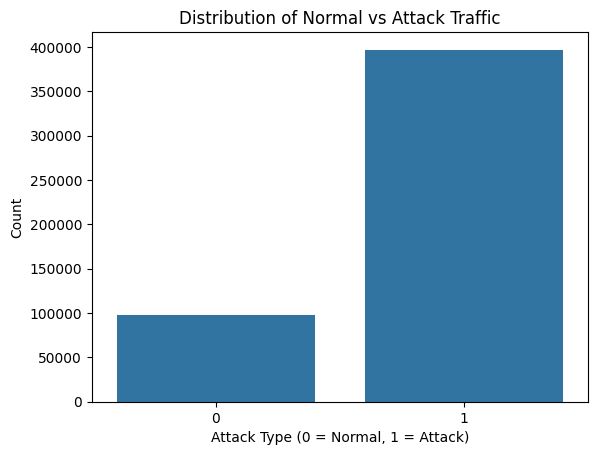

In [ ]:
# Plot target variable distribution
sns.countplot(x="attack_type", data=data)
plt.title("Distribution of Normal vs Attack Traffic")
plt.xlabel("Attack Type (0 = Normal, 1 = Attack)")
plt.ylabel("Count")
plt.show()

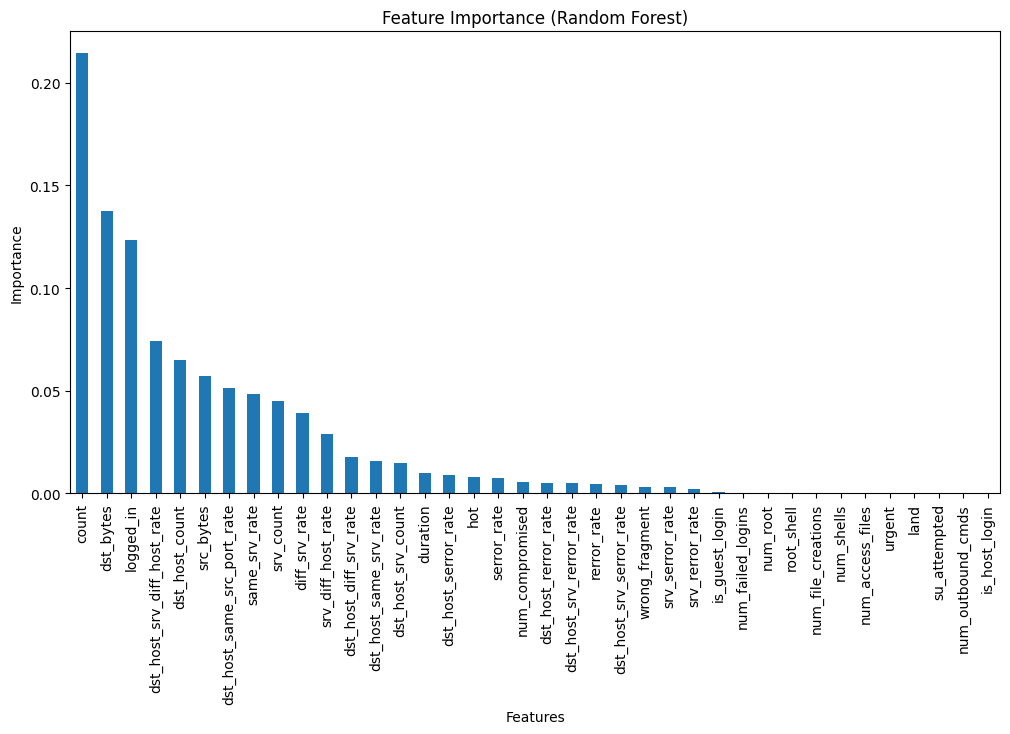

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Split features and target
X = data.drop(columns=["attack_type"])
y = data["attack_type"]

# Train a Random Forest for feature importance
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
top_10_features = importances.sort_values(ascending=False).head(10).index

# Plot feature importance
importances.plot(kind="bar", figsize=(12, 6))
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.show()


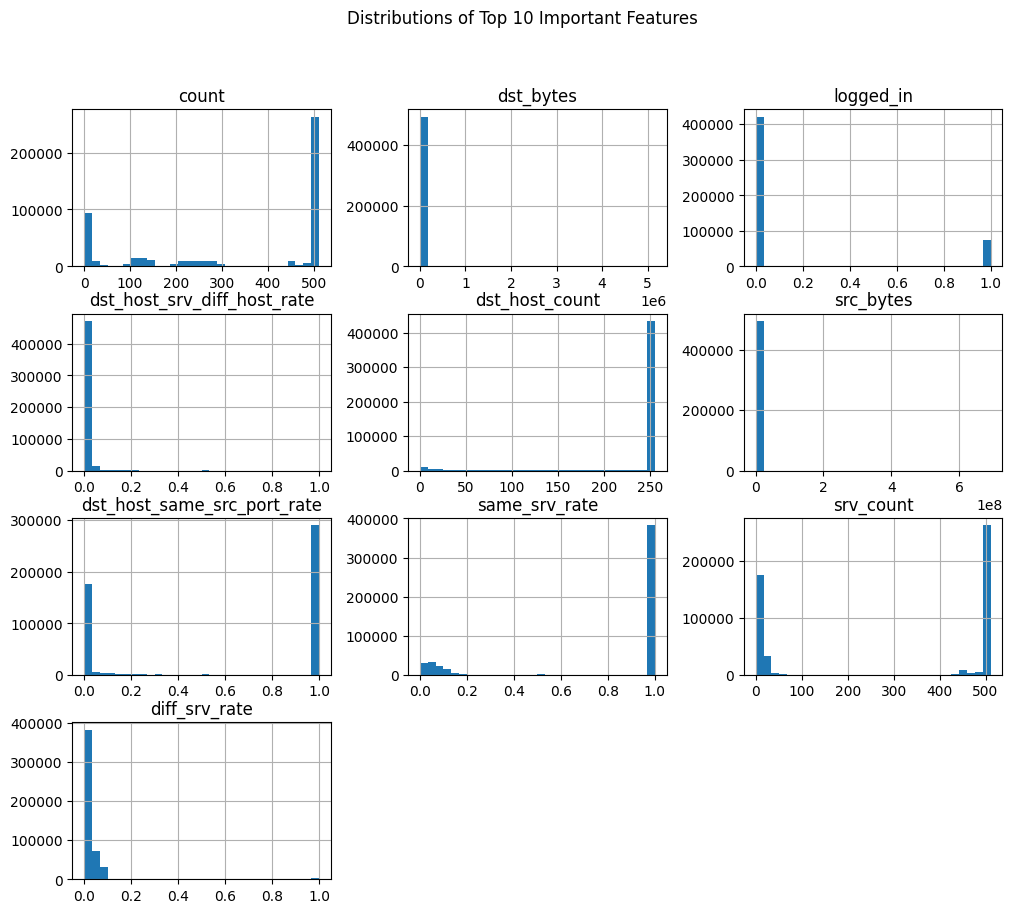

In [ ]:
# Plot histograms for the top 10 features
data[top_10_features].hist(bins=30, figsize=(12, 10))
plt.suptitle("Distributions of Top 10 Important Features")
plt.show()


In [ ]:
from scipy.stats import zscore

# Calculate Z-scores for the top 10 features
z_scores = data[top_10_features].apply(zscore)

# Identify outliers (Z-score > 3 or < -3)
outliers_z = (z_scores.abs() > 3)

# Count the number of outliers for each feature
outliers_count = outliers_z.sum()
print("Number of Outliers Detected for Each Feature:")
print(outliers_count)

# Identify rows with outliers in any feature
outliers_indices = outliers_z.any(axis=1)
# Filter the data to show rows with outliers in any of the top 10 features
outliers_data = data[outliers_z.any(axis=1)]
print(f"Total rows with outliers in at least one feature: {len(outliers_data)}")


Number of Outliers Detected for Each Feature:
count                              0
dst_bytes                        178
logged_in                          0
dst_host_srv_diff_host_rate     5567
dst_host_count                 26977
src_bytes                         60
dst_host_same_src_port_rate        0
same_srv_rate                      0
srv_count                          0
diff_srv_rate                   4679
dtype: int64
Total rows with outliers in at least one feature: 32320


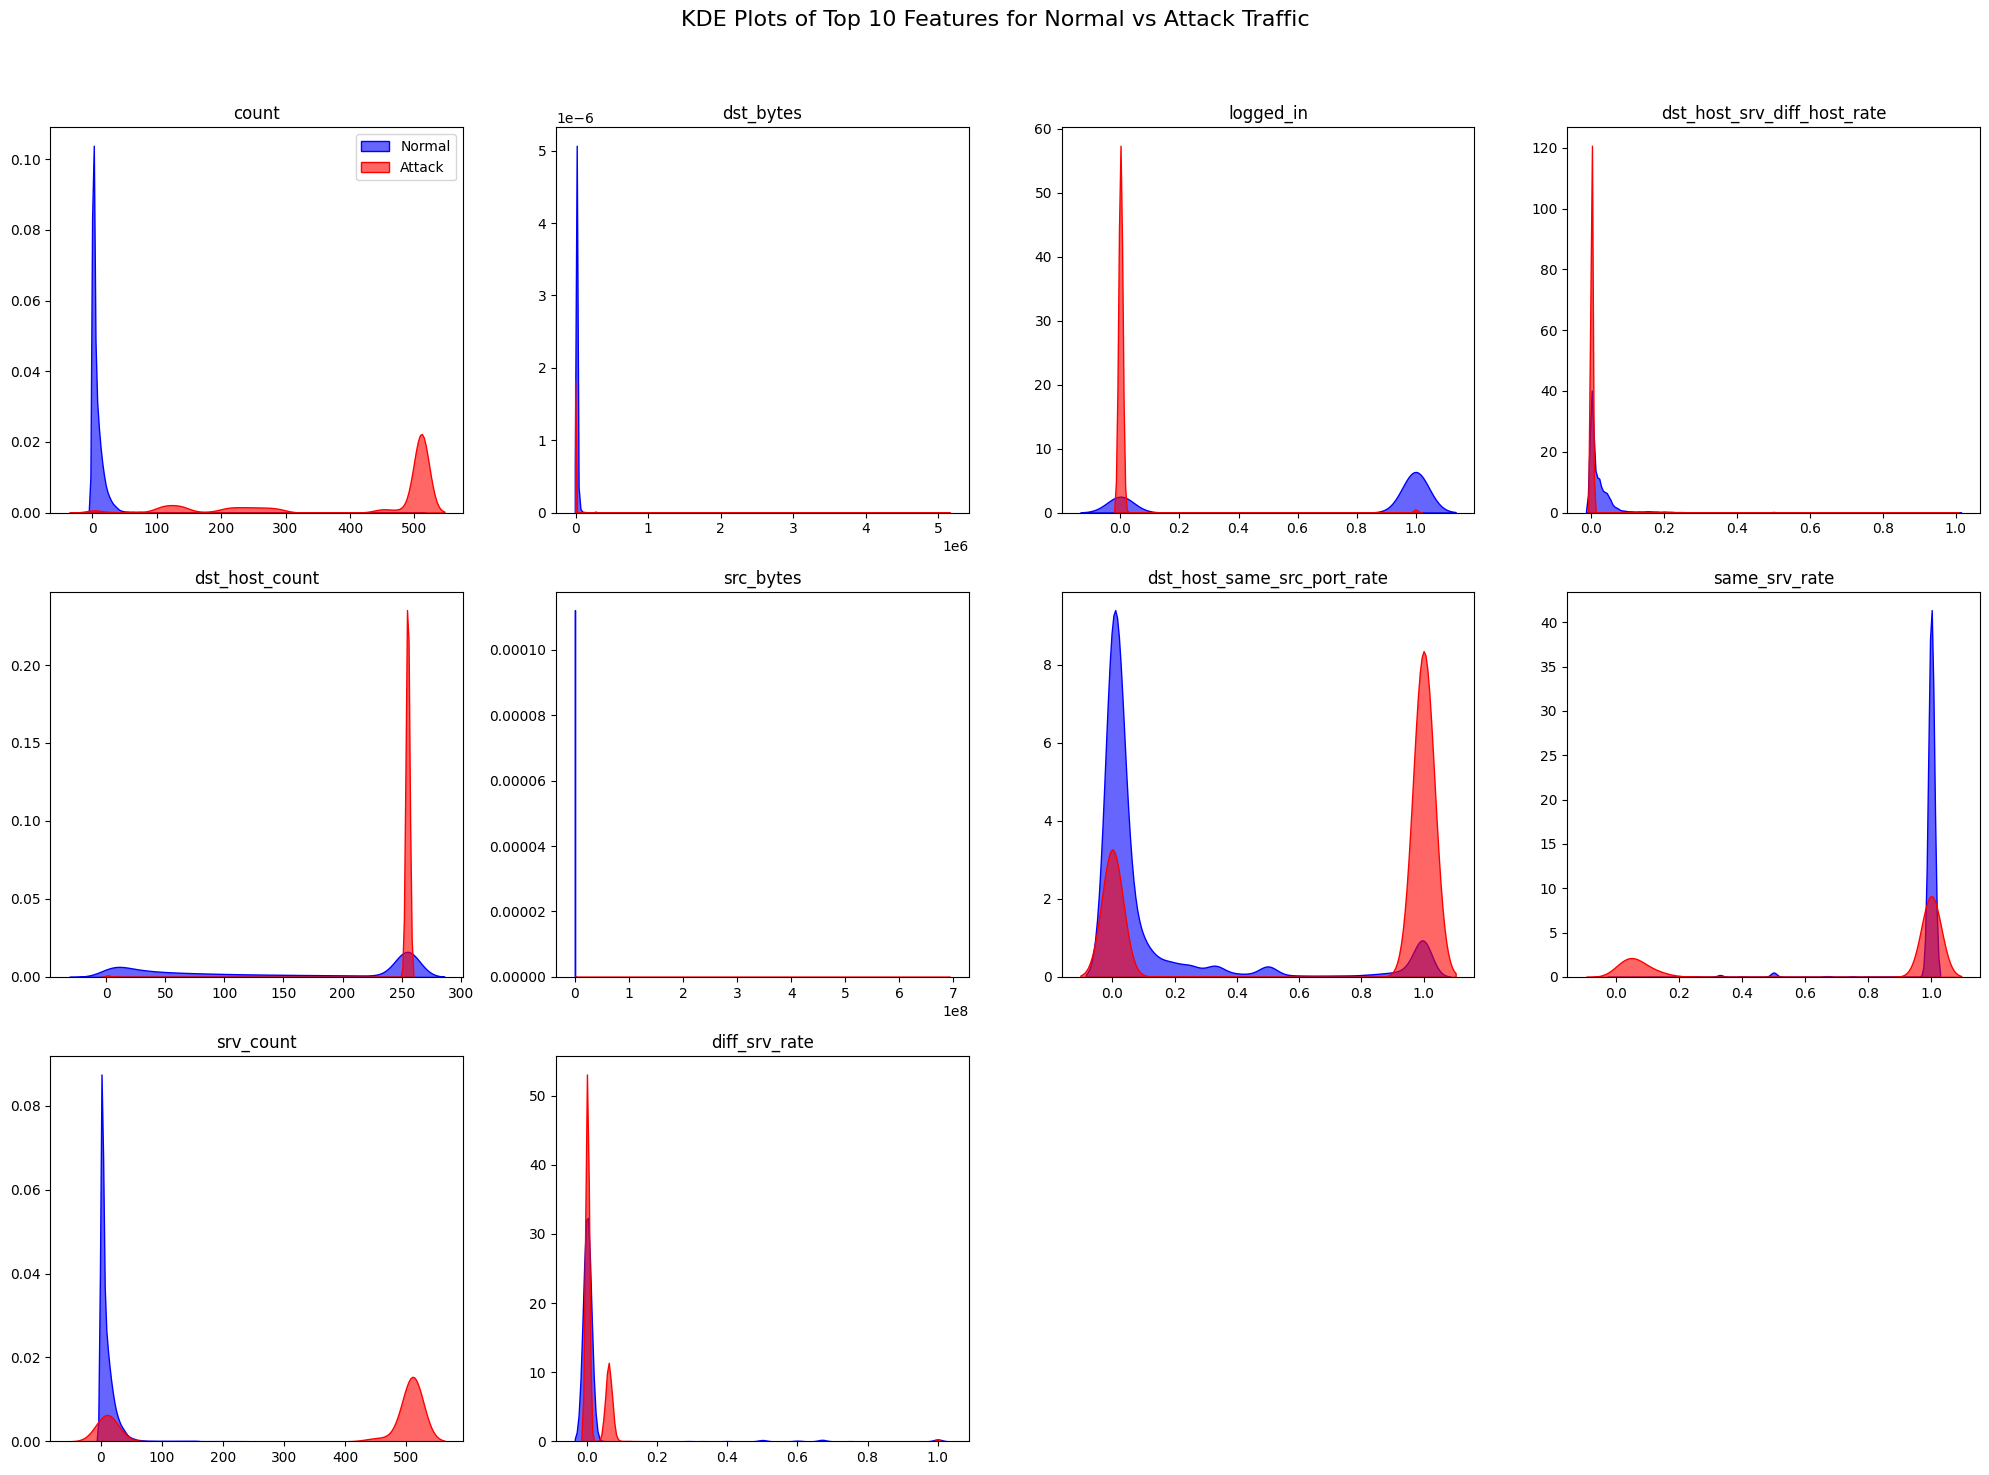

In [ ]:
plt.figure(figsize=(20, 15))
for i, feature in enumerate(top_10_features):
    plt.subplot(3, 4, i + 1)  # Adjust grid size to accommodate 10 plots
    sns.kdeplot(data[data["attack_type"] == 0][feature], label="Normal", fill=True, alpha=0.6, color="blue")
    sns.kdeplot(data[data["attack_type"] == 1][feature], label="Attack", fill=True, alpha=0.6, color="red")
    plt.title(f"{feature}")
    plt.xlabel("")
    plt.ylabel("")
    if i == 0:
        plt.legend()  # Show legend only in the first plot for clarity

plt.suptitle("KDE Plots of Top 10 Features for Normal vs Attack Traffic", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
# Step 1: Outlier Removal
# Use the boolean mask to filter out rows with outliers
data_cleaned = data[~outliers_indices]  # Rows without outliers

# Step 2: Balancing (Undersampling)
normal_data = data_cleaned[data_cleaned["attack_type"] == 0]
attack_data = data_cleaned[data_cleaned["attack_type"] == 1]
undersampled_attack_data = attack_data.sample(len(normal_data), random_state=42)
balanced_data = pd.concat([normal_data, undersampled_attack_data])

# Step 3: Standardization of Non-Binary Features
# Identify Non-Binary Features
binary_features = ['land', 'logged_in', 'root_shell','su_attempted ', 'is_host_login', 'is_guest_login', 'attack_type']
non_binary_features = [col for col in data.columns if col not in binary_features]

# Standardize Non-Binary Features (excluding 'attack_type')
scaler = StandardScaler()
balanced_data[non_binary_features] = scaler.fit_transform(balanced_data[non_binary_features])


In [ ]:
balanced_data.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type
count,1.393820e+05,1.393820e+05,1.393820e+05,139382.0,1.393820e+05,139382.0,1.393820e+05,1.393820e+05,139382.000000,1.393820e+05,...,1.393820e+05,1.393820e+05,1.393820e+05,1.393820e+05,1.393820e+05,1.393820e+05,1.393820e+05,1.393820e+05,1.393820e+05,139382.000000
mean,-5.212509e-18,2.832470e-18,-1.921874e-17,0.0,2.130884e-17,0.0,1.689286e-17,3.257022e-18,0.363641,-5.261894e-18,...,8.768231e-18,-5.656783e-16,-5.164080e-17,2.854773e-17,4.695082e-17,1.692472e-17,3.145348e-17,-5.287702e-17,3.058685e-18,0.500000
std,1.000004e+00,1.000004e+00,1.000004e+00,0.0,1.000004e+00,0.0,1.000004e+00,1.000004e+00,0.481049,1.000004e+00,...,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,0.500002
min,-1.195416e-01,-4.637749e-02,-2.875993e-01,0.0,-3.764698e-02,0.0,-4.736014e-02,-6.185920e-03,0.000000,-8.477998e-03,...,-1.991000e+00,-2.082781e+00,-2.857043e-01,-8.439107e-01,-3.743968e-01,-3.527352e-01,-3.513003e-01,-1.936365e-01,-1.903732e-01,0.000000
25%,-1.195416e-01,-4.013439e-02,-2.875993e-01,0.0,-3.764698e-02,0.0,-4.736014e-02,-6.185920e-03,0.000000,-8.477998e-03,...,-4.661685e-01,-6.216101e-02,-2.857043e-01,-8.439107e-01,-3.743968e-01,-3.527352e-01,-3.513003e-01,-1.936365e-01,-1.903732e-01,0.000000
50%,-1.195416e-01,-3.307883e-02,-2.875993e-01,0.0,-3.764698e-02,0.0,-4.736014e-02,-6.185920e-03,0.000000,-8.477998e-03,...,6.083769e-01,5.759295e-01,-2.857043e-01,-8.231383e-01,-3.743968e-01,-3.527352e-01,-3.513003e-01,-1.936365e-01,-1.903732e-01,0.500000
75%,-1.195416e-01,-2.248177e-03,-1.895076e-01,0.0,-3.764698e-02,0.0,-4.736014e-02,-6.185920e-03,1.000000,-8.477998e-03,...,6.083769e-01,5.759295e-01,-1.408608e-01,1.233332e+00,-3.743968e-01,-3.527352e-01,-3.513003e-01,-1.936365e-01,-1.903732e-01,1.000000
max,5.545108e+01,9.379764e+01,2.431813e+01,0.0,2.696395e+01,0.0,3.715620e+01,2.155453e+02,1.000000,3.471732e+02,...,6.083769e-01,5.759295e-01,6.956470e+00,1.233332e+00,9.515309e+00,2.853200e+00,2.857548e+00,5.498092e+00,5.476301e+00,1.000000


In [ ]:
balanced_data

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type
3,-0.119542,-0.037013,0.041920,0,-0.037647,0.0,-0.04736,-0.006186,1,-0.008478,...,-1.602117,0.575929,-0.285704,-0.781593,-0.374397,-0.352735,-0.351300,-0.193636,-0.190373,0
4,-0.119542,-0.037098,0.213210,0,-0.037647,0.0,-0.04736,-0.006186,1,-0.008478,...,-1.499779,0.575929,-0.285704,-0.802366,-0.374397,-0.352735,-0.351300,-0.193636,-0.190373,0
5,-0.119542,-0.037098,0.213210,0,-0.037647,0.0,-0.04736,-0.006186,1,-0.008478,...,-1.397441,0.575929,-0.285704,-0.802366,-0.374397,-0.352735,-0.351300,-0.193636,-0.190373,0
17,-0.119542,-0.035388,-0.085994,0,-0.037647,0.0,-0.04736,-0.006186,1,-0.008478,...,-0.169389,0.575929,-0.285704,-0.802366,1.907843,-0.352735,-0.351300,-0.193636,-0.190373,0
18,-0.119542,-0.036414,-0.224752,0,-0.037647,0.0,-0.04736,-0.006186,1,-0.008478,...,-0.067052,0.575929,-0.285704,-0.802366,1.907843,-0.352735,-0.351300,-0.193636,-0.190373,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278705,-0.119542,-0.002248,-0.287599,0,-0.037647,0.0,-0.04736,-0.006186,0,-0.008478,...,0.608377,0.575929,-0.285704,1.233332,-0.374397,-0.352735,-0.351300,-0.193636,-0.190373,1
325512,-0.119542,-0.002248,-0.287599,0,-0.037647,0.0,-0.04736,-0.006186,0,-0.008478,...,0.608377,0.575929,-0.285704,1.233332,-0.374397,-0.352735,-0.351300,-0.193636,-0.190373,1
117558,-0.119542,-0.046377,-0.287599,0,-0.037647,0.0,-0.04736,-0.006186,0,-0.008478,...,-1.888662,-1.976432,0.148826,-0.843911,-0.374397,2.853200,2.857548,-0.193636,-0.190373,1
218497,-0.119542,-0.002248,-0.287599,0,-0.037647,0.0,-0.04736,-0.006186,0,-0.008478,...,0.608377,0.575929,-0.285704,1.233332,-0.374397,-0.352735,-0.351300,-0.193636,-0.190373,1


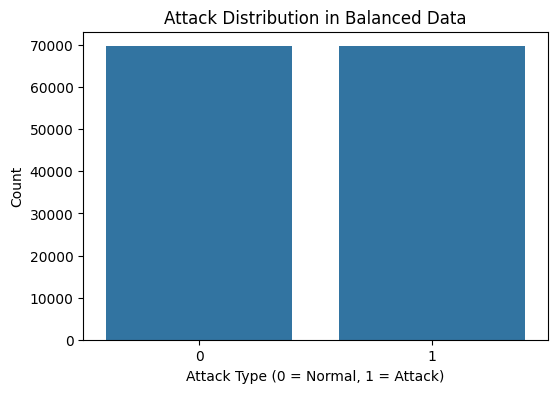

In [ ]:
# 1. **Attack Distribution**
plt.figure(figsize=(6, 4))
sns.countplot(x='attack_type', data=balanced_data)
plt.title('Attack Distribution in Balanced Data')
plt.xlabel('Attack Type (0 = Normal, 1 = Attack)')
plt.ylabel('Count')
plt.show()

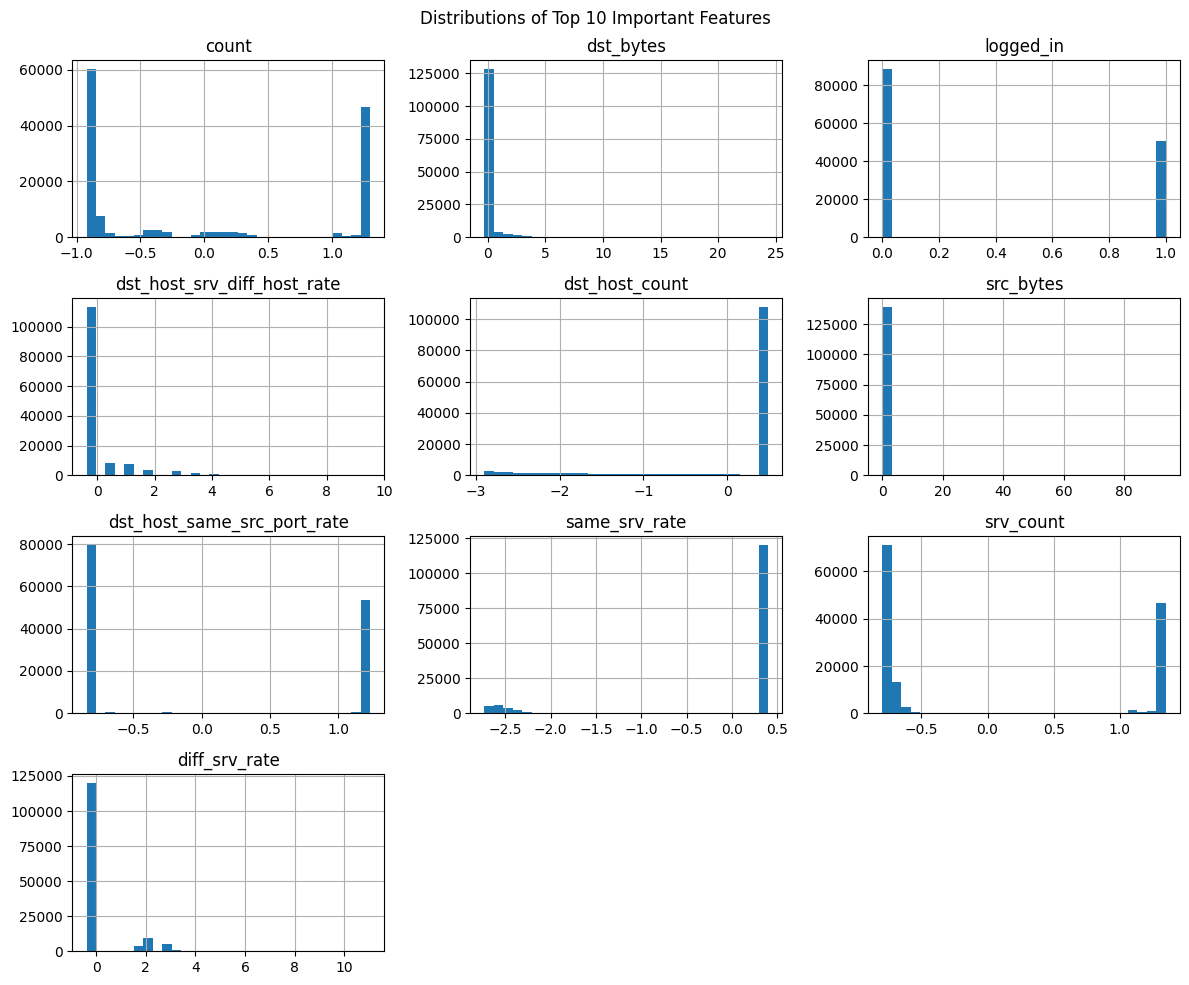

In [ ]:
# 2. **Top 10 Feature Distribution using Histograms**
# Plot histograms for the top 10 features
balanced_data[top_10_features].hist(bins=30, figsize=(12, 10))
plt.suptitle("Distributions of Top 10 Important Features")
plt.tight_layout()
plt.show()

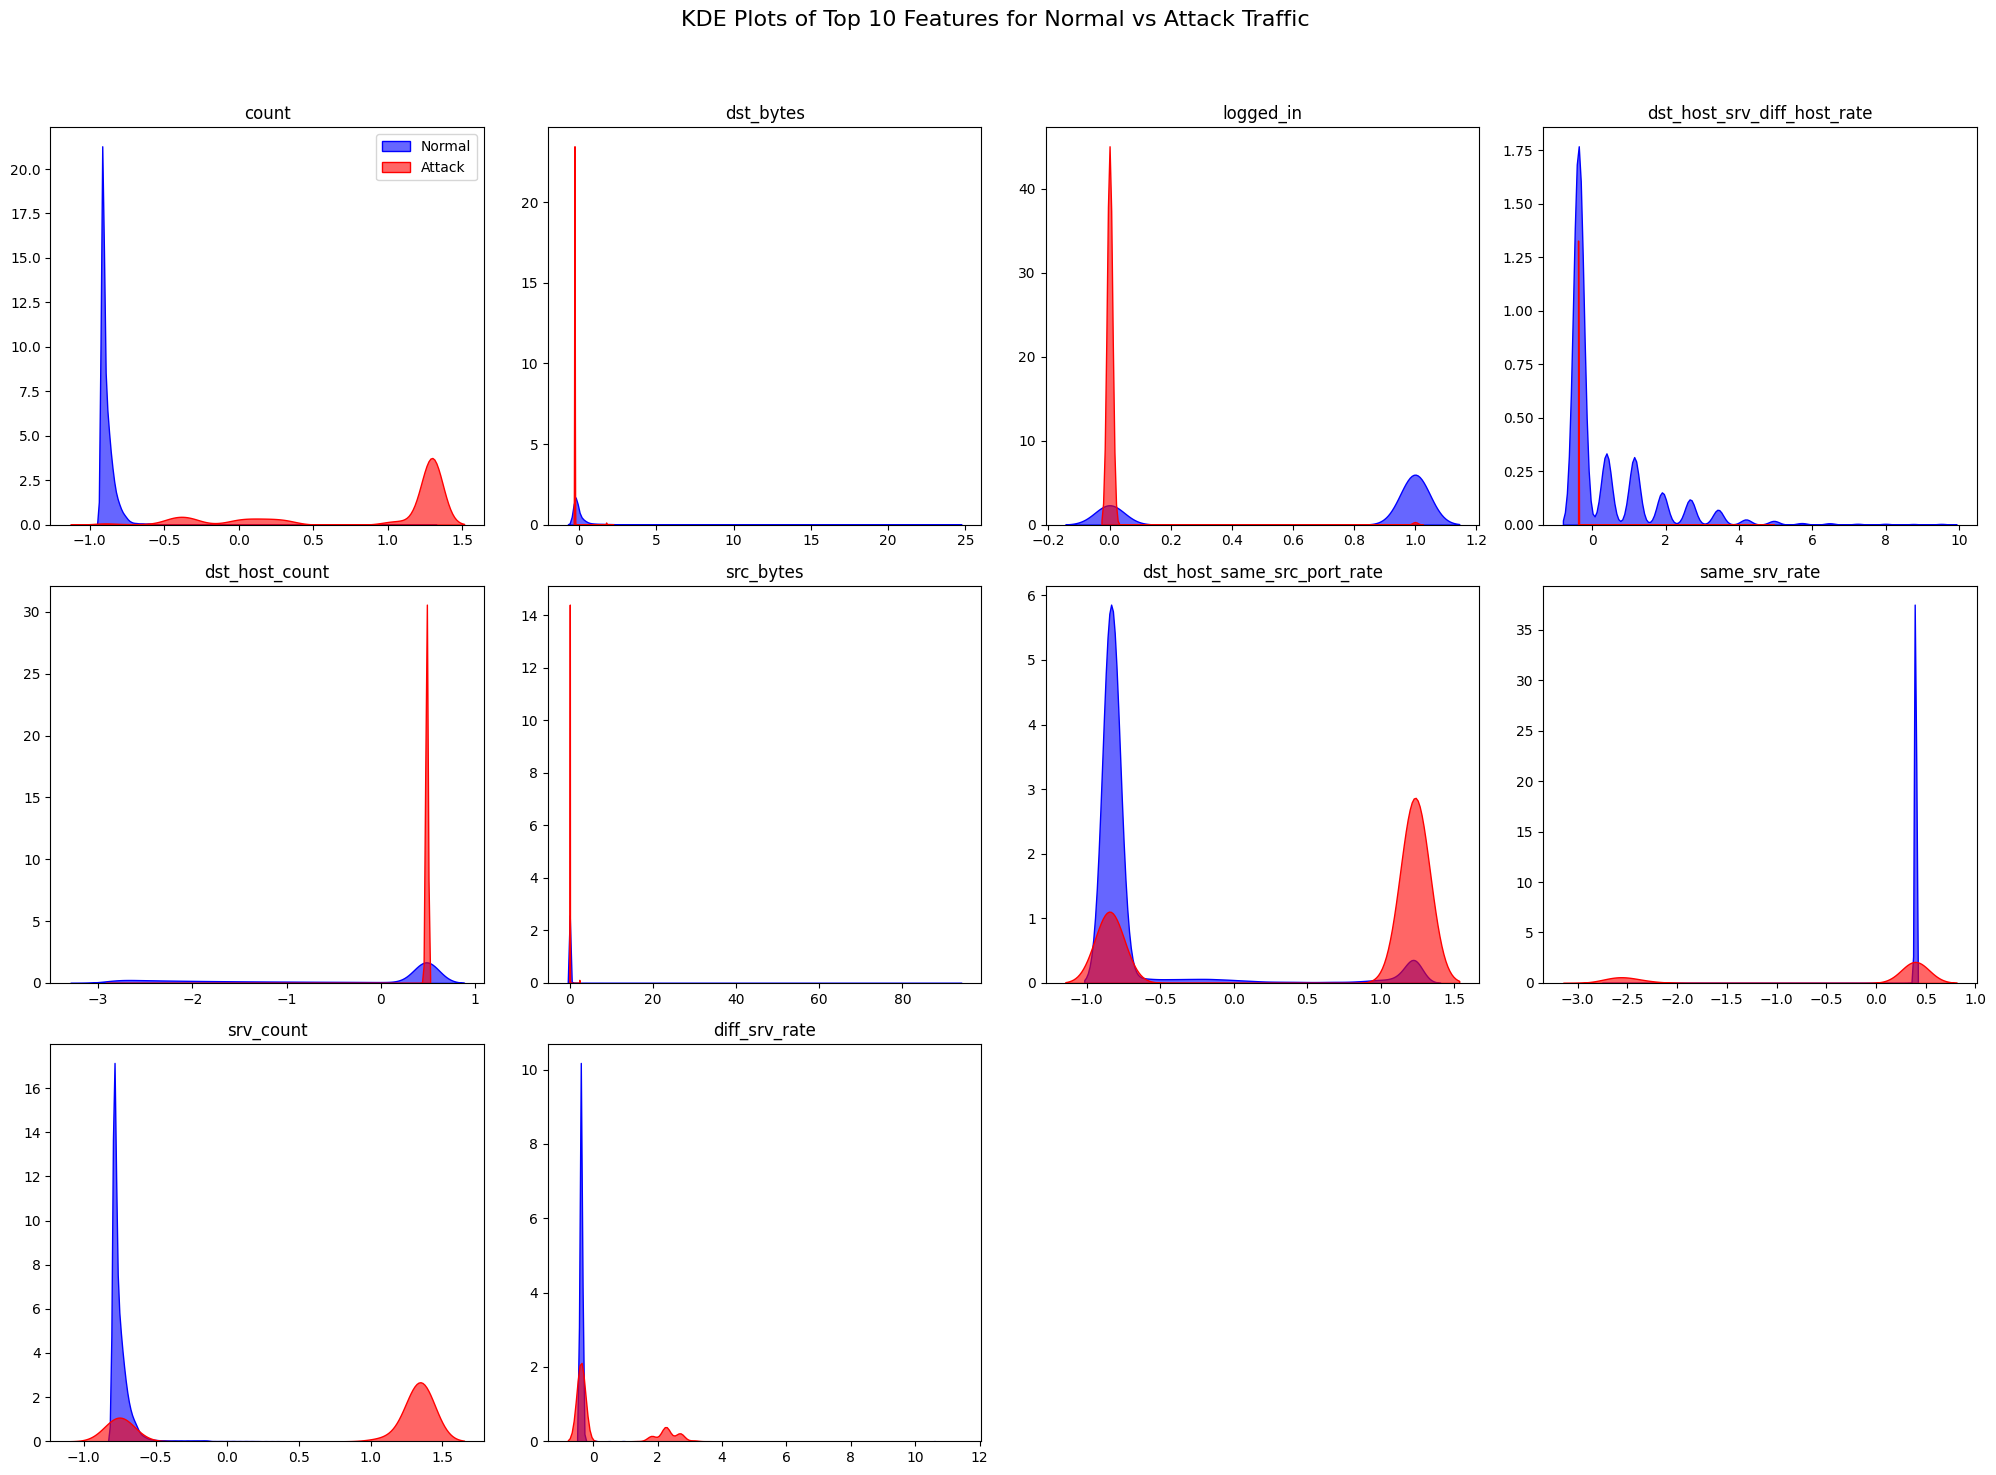

In [ ]:
# 3. **Top 10 Feature Distribution using KDE**
plt.figure(figsize=(20, 15))
for i, feature in enumerate(top_10_features):
    plt.subplot(3, 4, i + 1)  # Adjust grid size for 10 plots
    sns.kdeplot(balanced_data[balanced_data["attack_type"] == 0][feature], label="Normal", fill=True, alpha=0.6, color="blue")
    sns.kdeplot(balanced_data[balanced_data["attack_type"] == 1][feature], label="Attack", fill=True, alpha=0.6, color="red")
    plt.title(f"{feature}")
    plt.xlabel("")
    plt.ylabel("")
    if i == 0:
        plt.legend()  # Show legend only in the first plot for clarity

plt.suptitle("KDE Plots of Top 10 Features for Normal vs Attack Traffic", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
# 4. **Z-Score Outlier Detection for Balanced Data**
# Calculate Z-scores for the top 10 features
z_scores_balanced = balanced_data[top_10_features].apply(zscore)

# Identify outliers (Z-score > 3 or < -3)
outliers_z_balanced = (z_scores_balanced.abs() > 3)

# Count the number of outliers for each feature
outliers_count_balanced = outliers_z_balanced.sum()
print("Number of Outliers Detected for Each Feature in Balanced Data:")
print(outliers_count_balanced)

# Identify rows with outliers in any feature
outliers_indices_balanced = outliers_z_balanced.any(axis=1)

# Filter the data to show rows with outliers in any of the top 10 features
outliers_data_balanced = balanced_data[outliers_z_balanced.any(axis=1)]
print(f"Total rows with outliers in at least one feature: {len(outliers_data_balanced)}")

Number of Outliers Detected for Each Feature in Balanced Data:
count                             0
dst_bytes                      2571
logged_in                         0
dst_host_srv_diff_host_rate    3434
dst_host_count                    0
src_bytes                        68
dst_host_same_src_port_rate       0
same_srv_rate                     0
srv_count                         0
diff_srv_rate                  1048
dtype: int64
Total rows with outliers in at least one feature: 6942
